# Data Cleaning and Validation

In [55]:
#Importing Libraries for use

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
# Reading csv file into a dataframe using pandas and preview

data = pd.read_csv("data.csv")
data.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [57]:
# Check data types and non-null counts for each column

data.info() 
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [58]:
# Descriptive statistical summary of data for range validation of metrics

data.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [59]:
# Expected valid ranges for each metric

expected_ranges = {
    'completion_rate': (0, 1),
    'dropout_rate': (0, 1),
    'avg_watch_time': (0, 1),
    'assignment_submission_rate': (0, 1),
    'forum_activity_rate': (0, 1),
    'feedback_response_rate': (0, 1),
    'avg_feedback_score': (1, 5),
}

# Check each column against its expected range

for col, (low, high) in expected_ranges.items():
    within_range = data[col].between(low, high).all()
    print(f"{col}: within [{low}, {high}] -> {within_range}")

completion_rate: within [0, 1] -> True
dropout_rate: within [0, 1] -> True
avg_watch_time: within [0, 1] -> True
assignment_submission_rate: within [0, 1] -> True
forum_activity_rate: within [0, 1] -> True
feedback_response_rate: within [0, 1] -> True
avg_feedback_score: within [1, 5] -> True


In [60]:
# Checking Batch_id column for duplicates

data['batch_id'].nunique()

2000

In [61]:
# Checking dataframe for duplicate rows (redundant as batch id comes out unique)

print(data.duplicated().sum())

0


In [62]:
# Checking instructor_id and course_id columns for case-sensitive uniqueness

print(data['instructor_id'].str.upper().nunique())
print(data['course_id'].str.upper().nunique())

120
25


In [63]:
data[['completion_rate','dropout_rate']].corr()

,completion_rate,dropout_rate
completion_rate,1.000000,-0.953493
dropout_rate,-0.953493,1.000000


## Data Cleaning

Before defining instructor effectiveness, I checked the dataset for common data 
quality issues: missing values, out-of-range values, duplicate records, and 
identifier consistency.

**Missing values**: None. Every column in the dataset had zero null values 
(`df.isnull().sum()`), so no imputation or row-dropping was required.

**Range validation**: I checked the min/max of every metric against its expected 
valid range as described in the handbook (e.g., rates between 0–1, feedback 
score between 1–5). All values fell within their expected bounds — no invalid 
or out-of-range entries were found.

**Duplicates**: `batch_id` is unique across all 2000 rows, confirming there are 
no duplicate batch records.

**Identifier consistency**: `instructor_id` and `course_id` values follow a 
consistent format and length across all rows, with no obvious formatting 
inconsistencies (e.g., casing mismatches) that would cause the same instructor 
or course to be split into separate groups.

**Redundant features**: `completion_rate` and `dropout_rate` showed a strong 
negative correlation (-0.95). While not perfectly collinear — implying some 
learners are neither "completed" nor "dropped out" (e.g., still in progress) — 
the two variables capture largely the same underlying signal. Including both 
in the effectiveness score would over-weight this signal relative to other 
metrics. I chose to retain `completion_rate` and exclude `dropout_rate` from 
further analysis, since completion is the more direct, intuitive measure of 
learner outcomes.

**Conclusion**: The dataset required no traditional cleaning (no missing data, 
no invalid values, no duplicates). The main pre-modeling decision was handling 
the completion/dropout redundancy, which I treated as a feature selection 
choice rather than a cleaning issue.

# Exploratory Data Analysis and Visualisation

In [64]:
# General summary statistics 

data.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


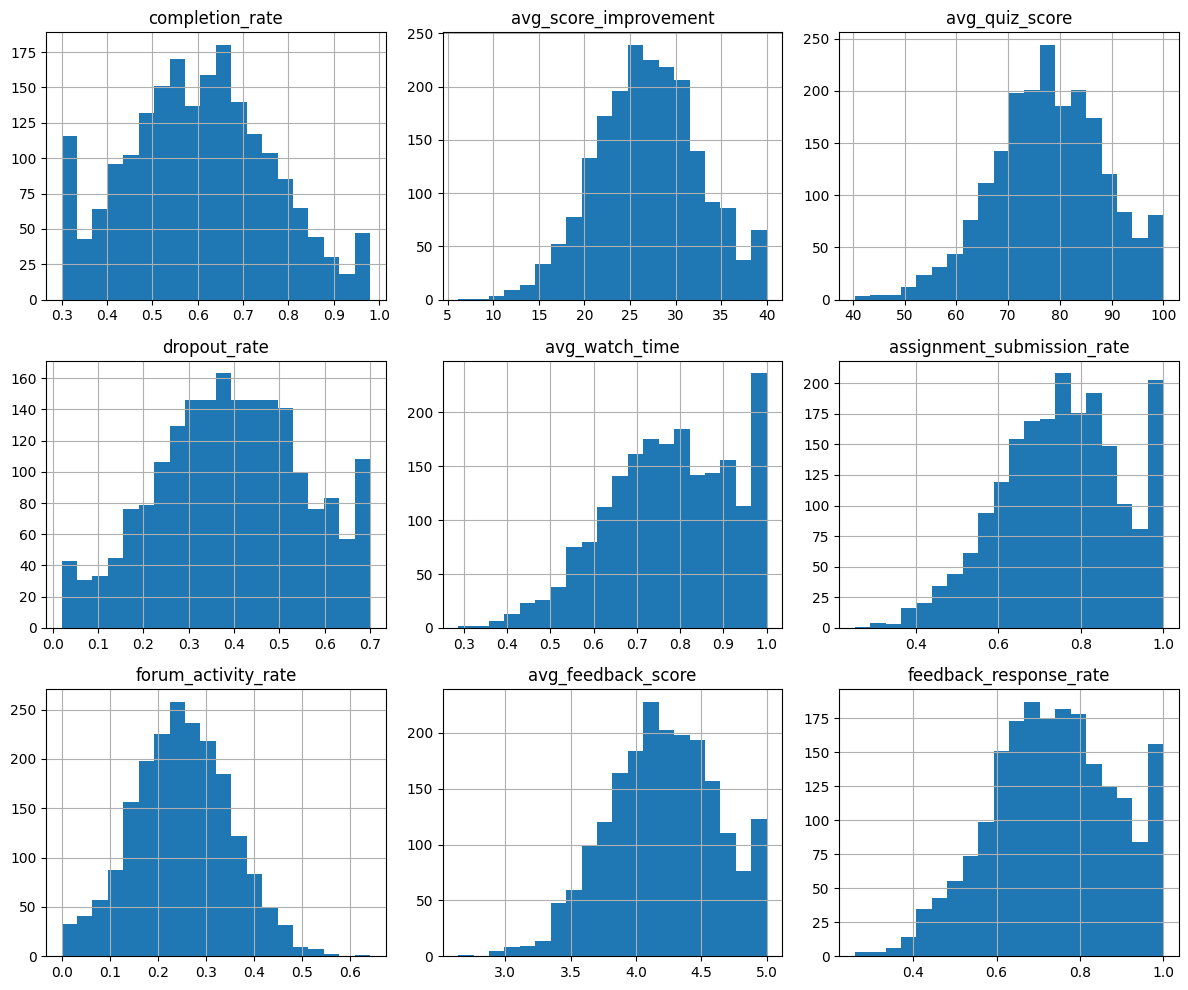

In [65]:
# Plotting histograms for each metric to identify patterns and information

data.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.savefig('metrics_plot.png')
plt.show()

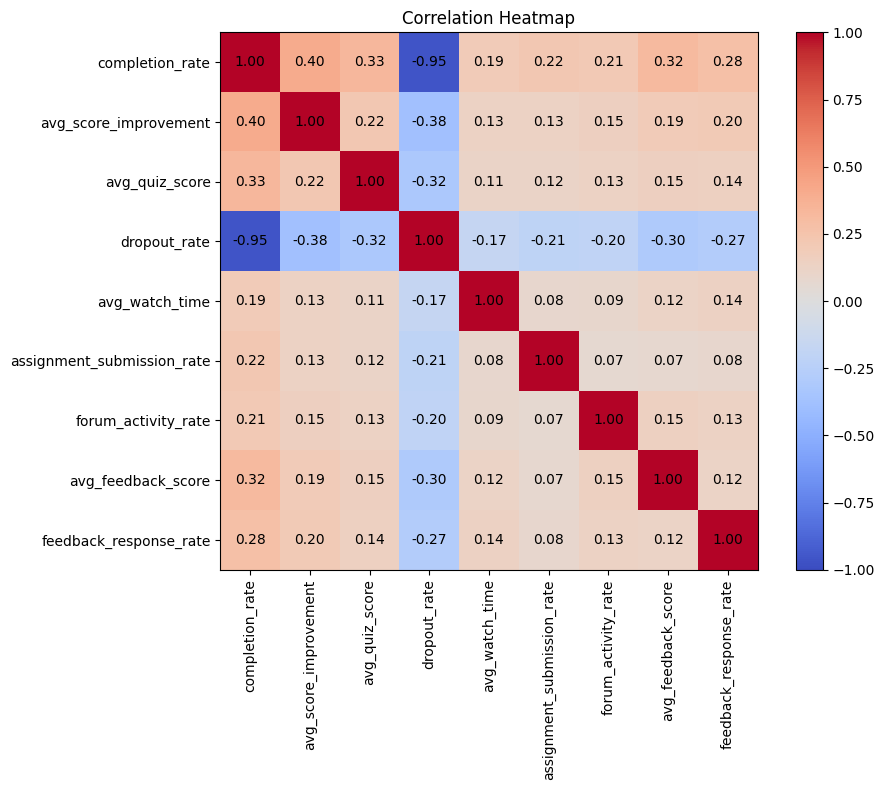

In [66]:
# Plotting a correlation heatmap for all given metrics to identify trends apart from the completion rate and drop rate 

corr = data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# axis labels

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Colorbar
fig.colorbar(im, ax=ax)

# Annotate each cell with the correlation value
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

In [67]:
# Group by course_id and look at average completion_rate per course

course_avg = data.groupby('course_id')['completion_rate'].mean().sort_values()
print(course_avg)

course_id
C_09    0.561902
C_08    0.571638
C_22    0.574229
C_16    0.580683
C_19    0.589855
C_15    0.590982
C_03    0.592443
C_13    0.592635
C_10    0.592842
C_23    0.593806
C_04    0.597575
C_07    0.598774
C_18    0.599867
C_02    0.601831
C_12    0.606735
C_17    0.607274
C_11    0.607435
C_01    0.611400
C_25    0.616483
C_24    0.617382
C_06    0.622184
C_21    0.625749
C_05    0.630338
C_14    0.639152
C_20    0.639422
Name: completion_rate, dtype: float64


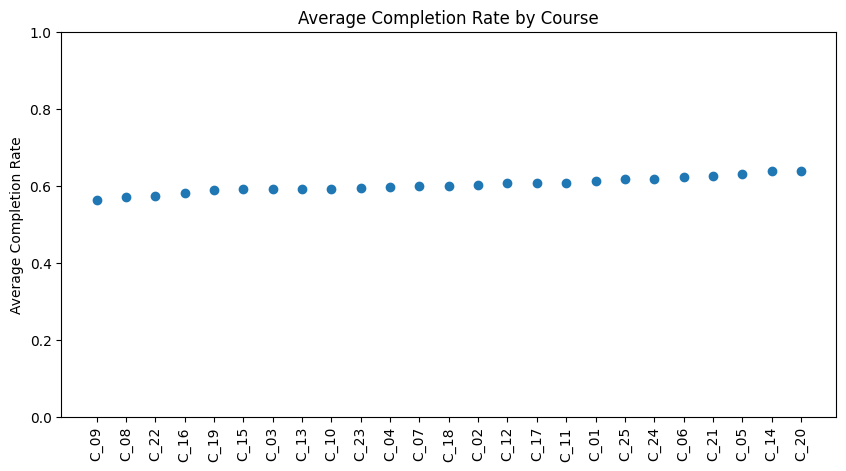

In [75]:
# Plotting a scatter chart for avg_completion_rate per course

plt.figure(figsize=(10,5))
plt.scatter(course_avg.index, course_avg.values)
plt.ylabel('Average Completion Rate')
plt.title('Average Completion Rate by Course')
plt.xticks(rotation=90)
plt.ylim(0, 1) 
plt.savefig('Avg_Completion_Rate_per_Course.png')
plt.show()

In [69]:
# Group by course_id and look at average quiz_score per course

course_quiz = data.groupby('course_id')['avg_quiz_score'].mean().sort_values()
print(course_quiz)

course_id
C_16    76.146757
C_07    76.570166
C_17    76.594139
C_19    76.714415
C_08    76.880615
C_05    76.924427
C_03    77.091312
C_09    77.106312
C_23    77.109156
C_01    77.458578
C_18    77.770557
C_12    77.824460
C_14    78.071778
C_15    78.112734
C_22    78.160854
C_13    78.169013
C_02    78.197494
C_10    78.212515
C_21    78.740188
C_20    78.828736
C_04    78.883837
C_06    79.016035
C_24    79.136514
C_25    80.003882
C_11    80.611406
Name: avg_quiz_score, dtype: float64


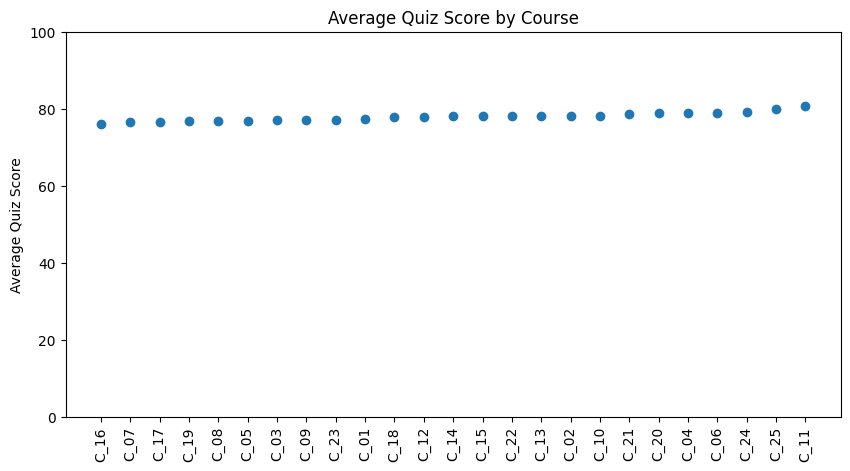

In [74]:
#Plotting a scatter chart for quiz_score per course

plt.figure(figsize=(10,5))
plt.scatter(course_quiz.index, course_quiz.values)
plt.ylabel('Average Quiz Score')
plt.title('Average Quiz Score by Course')
plt.xticks(rotation=90)
plt.ylim(0, 100) 
plt.savefig('Avg_Quiz_Score_by_Course.png')
plt.show()

### Observations: Average Quiz Score and Completion Rate by Course

* The average completion rate across most courses is close to **0.6 (60%)**, indicating that learner retention is relatively consistent across different courses.
* Similarly, the average quiz scores for most courses lie within a narrow range of **76–80 marks**, suggesting that learner performance does not vary significantly between courses. (assuming a range of 0-100)
* The limited variation in these metrics implies that no particular course appears to be substantially easier or more difficult than the others based on the available data.
* Since course-level differences are relatively small, factors such as instructor behavior, learner engagement, and batch-specific characteristics may play a more important role in explaining differences in instructor effectiveness.
* However, course effects cannot be completely ruled out and should still be considered as a potential confounding factor in the analysis.


count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64


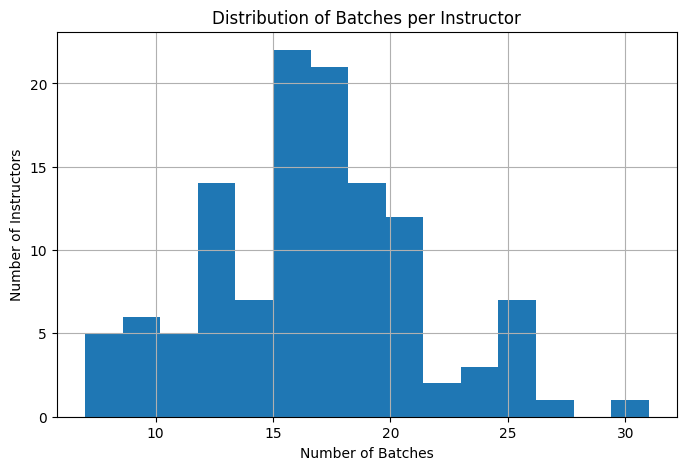

In [77]:
# Distribution of the Number of Batches Taught per Instructor

batch_counts = data.groupby('instructor_id').size()
print(batch_counts.describe())

plt.figure(figsize=(8,5))
batch_counts.hist(bins=15)
plt.xlabel('Number of Batches')
plt.ylabel('Number of Instructors')
plt.title('Distribution of Batches per Instructor')
plt.savefig('Distribution_of_Batches_per_Instructor.png')
plt.show()

### Observations: Distribution of Batches per Instructor
* The number of batches taught per instructor ranges from approximately 7 to 31 batches.
  
* Most instructors teach between 14 and 20 batches, indicating that the majority have a moderate amount of teaching history on the platform.

* The distribution is approximately bell-shaped with a slight right skew, as a small number of instructors teach substantially more batches than the average.
 
* Instructors with a larger number of batches provide more historical data, making their aggregated performance metrics potentially more reliable and stable.

* Conversely, effectiveness estimates for instructors with relatively few batches may be more sensitive to the outcomes of individual batches.
Therefore, the number of batches taught `batch_count` may itself be a useful feature when modeling instructor effectiveness and should be considered during interpretation.